In [42]:
# 아미지 이름을 보면 '.'을 기준으로 label이 저장되어있음
import os

path = './train'
os.listdir(path)[:5]

['cat.0.jpg', 'cat.1.jpg', 'cat.10.jpg', 'cat.100.jpg', 'cat.1000.jpg']

In [43]:
# '.'을 기준으로 나누어 이미지 이름과 label 저장
full_names = os.listdir(path)
labels = [name.split('.')[0] for name in full_names]
file_id = [name.split('.')[1] for name in full_names]

print(labels[:5])
print(file_id[:5])

['cat', 'cat', 'cat', 'cat', 'cat']
['0', '1', '10', '100', '1000']


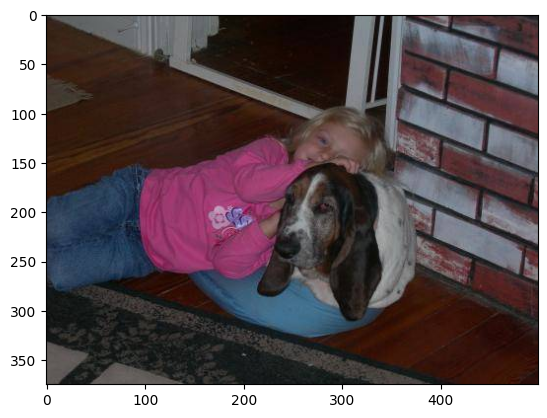

In [44]:
# 이미지 확인
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

sample = random.choice(full_names)
image = mpimg.imread(path + '/' + sample)

plt.imshow(image)
plt.show()

In [45]:
# 이미지 크기 확인
# 이미지 크기는 모두 다름
samples = random.choices(population=full_names, k=3)
for sample in samples:
    image = mpimg.imread(path + '/' + sample)
    print(image.shape)

(379, 500, 3)
(375, 499, 3)
(299, 485, 3)


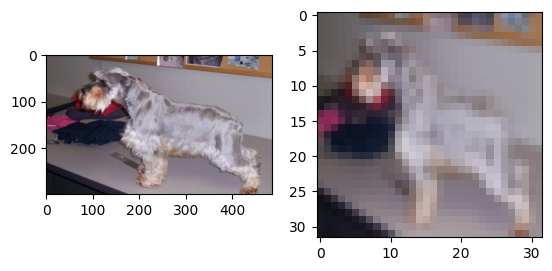

In [46]:
# Resize
from skimage.transform import resize

resized = resize(image, (32, 32, 3))

fig, axes = plt.subplots(1, 2)
axes[0].imshow(image)
axes[1].imshow(resized)
plt.show()

In [47]:
# 모든 이미지 Resize
from PIL import Image
import numpy as np
from tqdm.notebook import tqdm
import os

images = []
for name in tqdm(full_names):
    img = Image.open(os.path.join(path, name))
    img = img.convert('RGB')
    img = img.resize((32, 32), resample=Image.BILINEAR)
    arr = np.array(img, dtype=np.float32) / 255.0
    images.append(arr)

images = np.stack(images)

print(images.shape)
print(images.dtype)
print(labels[:3])


  0%|          | 0/25000 [00:00<?, ?it/s]

(25000, 32, 32, 3)
float32
['cat', 'cat', 'cat']


In [49]:
# cat, dog -> 0, 1
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels = le.fit_transform(labels)
labels[:3]

array([0, 0, 0])

In [50]:
labels_encoded = labels
labels_encoded[:3]

array([0, 0, 0])

In [51]:
le.classes_

array(['cat', 'dog'], dtype='<U3')

In [52]:
# Data Split
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(images,
                                                    labels_encoded,
                                                    test_size=0.2,
                                                    random_state=13,
                                                    stratify=labels_encoded)

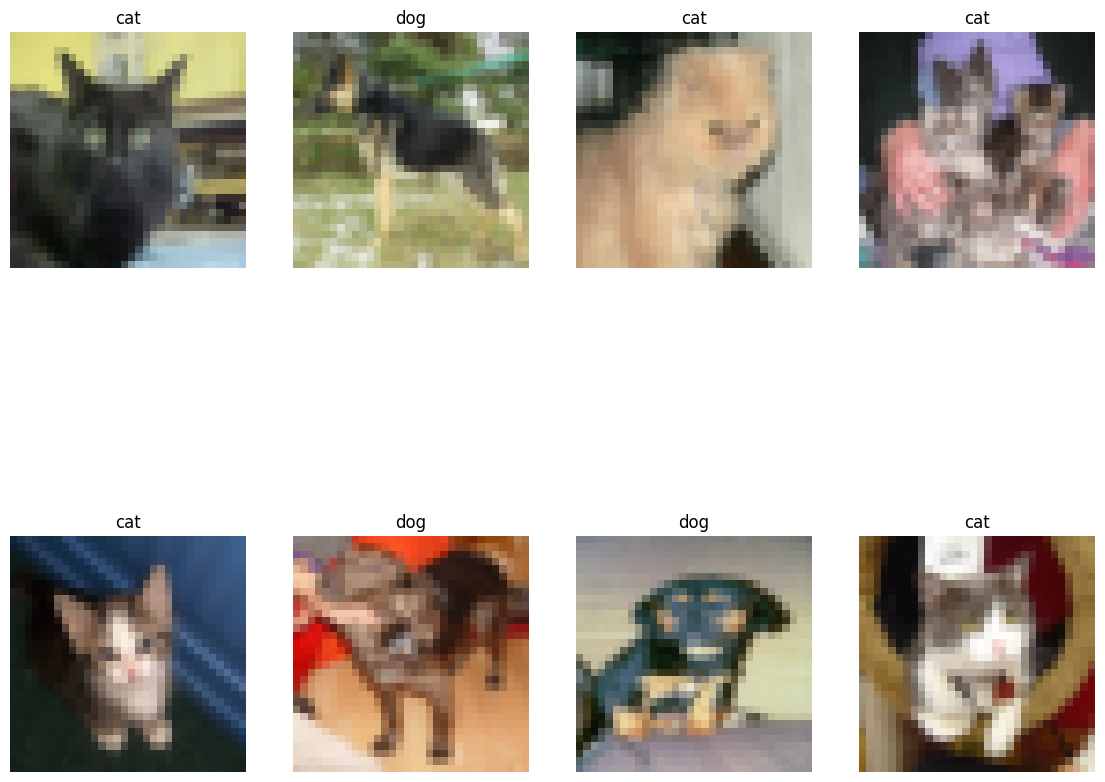

In [53]:
# Train Image Set
samples = random.choices(population=range(0, 20000), k=8)

plt.figure(figsize=(14, 12))

for idx, i in enumerate(samples):
    plt.subplot(2, 4, idx + 1)
    plt.imshow(x_train[i])
    plt.title(le.classes_[y_train[i]])
    plt.axis('off')
plt.show()

In [54]:
# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([
    Conv2D(32,
           (3, 3),
           activation='relu',
           input_shape=(32, 32, 3)),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),

    Conv2D(64,
           (3, 3),
           activation='relu',
           padding='same'),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),

    Conv2D(64,
           (3, 3),
           activation='relu',
           padding='same'),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512,
          activation='relu'),
    Dropout(0.25),
    Dense(2,
          activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 15, 15, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 3, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       295,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 352,770 (1.35 MB)

 Trainable params: 352,770 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [55]:
hist = model.fit(x_train,
                 y_train,
                 epochs=10,
                 validation_data=(x_test, y_test))

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.5374 - loss: 0.6889 - val_accuracy: 0.6956 - val_loss: 0.6011
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.6720 - loss: 0.6060 - val_accuracy: 0.7320 - val_loss: 0.5425
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7194 - loss: 0.5499 - val_accuracy: 0.7500 - val_loss: 0.5082
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7401 - loss: 0.5213 - val_accuracy: 0.7754 - val_loss: 0.4751
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7514 - loss: 0.4986 - val_accuracy: 0.7766 - val_loss: 0.4706
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.7735 - loss: 0.4731 - val_accuracy: 0.7966 - val_loss: 0.4479
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7847 - loss: 0.4580 - val_accuracy: 0.8060 - val_loss: 0.4290
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.7862 - loss: 0.4538 - val_accuracy

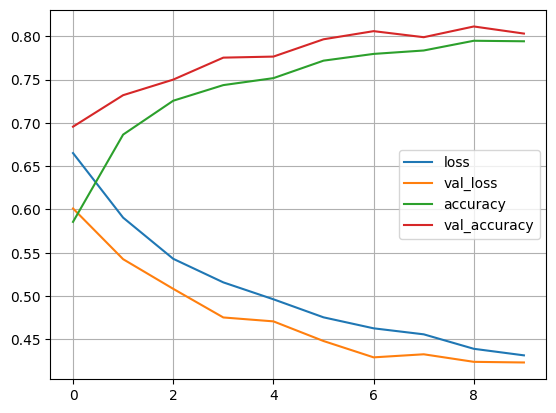

In [56]:
# Metrics
plot_target = ['loss', 'val_loss', 'accuracy', 'val_accuracy']

plt.figure()

for metric in plot_target:
    plt.plot(hist.history[metric], label=metric)

plt.legend()
plt.grid()
plt.show()

In [57]:
# ImageDataGenerator 준비
import os
import shutil

path = './train/'
classes = ['cat', 'dog']

for class_name in classes:
    class_path = os.path.join(path, class_name)
    os.makedirs(class_path, exist_ok=True)

    for file in full_names:
        if class_name in file:
            shutil.move(os.path.join(path, file), os.path.join(class_path, file))

In [59]:
# ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255.,
    validation_split=0.2
)

In [60]:
# Train Set
batch_size = 32

train_generator = datagen.flow_from_directory(
    path,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

Found 20000 images belonging to 2 classes.


In [61]:
validation_generator = datagen.flow_from_directory(
    path,
    target_size=(128, 128),
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 5000 images belonging to 2 classes.


In [64]:
# Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout

model = Sequential([
    Conv2D(32,
           (3, 3),
           activation='relu',
           input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),

    Conv2D(64,
           (3, 3),
           activation='relu',
           padding='same'),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),

    Conv2D(64,
           (3, 3),
           activation='relu',
           padding='same'),
    MaxPooling2D((2, 2),
                 strides=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(512,
          activation='relu'),
    Dropout(0.25),
    Dense(2,
          activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 63, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 31, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 31, 31, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 15, 15, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 14400)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 512)            │     7,373,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │         1,026 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,430,658 (28.35 MB)

 Trainable params: 7,430,658 (28.35 MB)

 Non-trainable params: 0 (0.00 B)

In [65]:
model.fit(
    train_generator,
    epochs=5,
    validation_data=validation_generator
)

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 249s 386ms/step - accuracy: 0.5576 - loss: 0.7673 - val_accuracy: 0.6938 - val_loss: 0.5722
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 130s 208ms/step - accuracy: 0.6901 - loss: 0.5841 - val_accuracy: 0.7440 - val_loss: 0.5178
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 126s 202ms/step - accuracy: 0.7438 - loss: 0.5101 - val_accuracy: 0.7654 - val_loss: 0.4848
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 120s 193ms/step - accuracy: 0.7767 - loss: 0.4688 - val_accuracy: 0.8084 - val_loss: 0.4300
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 118s 189ms/step - accuracy: 0.8046 - loss: 0.4188 - val_accuracy: 0.8110 - val_loss: 0.4063
